In [1]:
import os
import kagglehub

# Check how many images in each folder

# Download latest version
base_dir_downloaded = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")
base_dir = os.path.join(base_dir_downloaded, 'The IQ-OTHNCCD lung cancer dataset', 'The IQ-OTHNCCD lung cancer dataset')

print("Path to dataset files:", base_dir)
class_names = ['Bengin cases', 'Malignant cases', 'Normal cases']

for class_name in class_names:
    class_folder = os.path.join(base_dir, class_name);
    files = [f for f in os.listdir(class_folder)]
    print(f"Number of images in {class_name}: {len(files)}")

Path to dataset files: /kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset
Number of images in Bengin cases: 120
Number of images in Malignant cases: 561
Number of images in Normal cases: 416


In [2]:
import shutil
import random
from PIL import Image, ImageEnhance

# Reset output dir if already present
output_dir = "/kaggle/working/balanced_dataset"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# Define target count for each class after augmentation
target_count = 600
img_size = (512, 512)

def get_random_transform():
    options = [
        lambda img: img.transpose(Image.FLIP_LEFT_RIGHT),
        lambda img: img.transpose(Image.FLIP_TOP_BOTTOM),
        lambda img: img.rotate(random.uniform(-25, 25)),
        lambda img: ImageEnhance.Contrast(img).enhance(random.uniform(1.2, 1.8)),
        lambda img: ImageEnhance.Color(img).enhance(random.uniform(1.2, 2.0)),
        lambda img: ImageEnhance.Sharpness(img).enhance(random.uniform(1.5, 2.5))
    ]
    return random.choice(options)

def augment_and_save(class_name, target_count):
    class_src = os.path.join(base_dir, class_name)
    class_dst = os.path.join(output_dir, class_name)
    os.makedirs(class_dst)

    images = [f for f in os.listdir(class_src)]
    original_count = len(images)

    # Copy images to output_dir
    for img in images:
        shutil.copy(os.path.join(class_src, img), os.path.join(class_dst, img))

    # Check if original_count < target_count
    extra_needed = target_count - original_count
    if extra_needed <= 0:
        return

    print(f"Need to generate {extra_needed} new images for {class_name}")

    for i in range(extra_needed):
        img_name = random.choice(images)
        try:
            with Image.open(os.path.join(class_src, img_name)) as img:
                img = img.convert('RGB').resize(img_size)
                transformed_img = get_random_transform()(img)
                save_name = f"aug{i}_{img_name}"
                transformed_img.save(os.path.join(class_dst, save_name))
        except Exception as err:
            print(f"Error while augmenting: {err}")

for class_name in class_names:
    augment_and_save(class_name, target_count)

print("Augmentation complete for all classes!")

Need to generate 480 new images for Bengin cases
Need to generate 39 new images for Malignant cases
Need to generate 184 new images for Normal cases
Augmentation complete for all classes!


In [3]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

# Define data transformations
data_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset from the augmented data directory
full_dataset = ImageFolder(output_dir, transform=data_transforms)

# Split dataset into training and validation sets (80% train, 20% val)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Dataset prepared: {len(train_dataset)} training samples, {len(val_dataset)} validation samples.")

Dataset prepared: 1440 training samples, 360 validation samples.


In [4]:
import torchvision.models as models
import torch.nn as nn
import torch
# Load pretrained ResNet50
resnet50 = models.resnet50(pretrained=True)

num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_ftrs, 3)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet50 = resnet50.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 152MB/s]


In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50.parameters(), lr=0.0001)

# Training loop
epochs = 10
rn_train_losses = []
rn_train_accuracies = []
rn_val_losses = []
rn_val_accuracies = []

for epoch in range(epochs):
    resnet50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    rn_train_losses.append(epoch_loss)
    rn_train_accuracies.append(epoch_acc)

    # Validation loop
    resnet50.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet50(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    rn_val_losses.append(val_loss / len(val_loader))
    rn_val_accuracies.append(val_correct / val_total)

    print(f"Epoch {epoch+1}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {rn_val_losses[-1]:.4f}, Val Acc: {rn_val_accuracies[-1]:.4f}")

Epoch 1, Train Loss: 0.3688, Train Acc: 0.8493, Val Loss: 0.2729, Val Acc: 0.9139
Epoch 2, Train Loss: 0.0733, Train Acc: 0.9778, Val Loss: 0.2132, Val Acc: 0.9306
Epoch 3, Train Loss: 0.0522, Train Acc: 0.9840, Val Loss: 0.0907, Val Acc: 0.9611
Epoch 4, Train Loss: 0.0207, Train Acc: 0.9951, Val Loss: 0.0544, Val Acc: 0.9806
Epoch 5, Train Loss: 0.0046, Train Acc: 0.9993, Val Loss: 0.0335, Val Acc: 0.9861
Epoch 6, Train Loss: 0.0089, Train Acc: 0.9979, Val Loss: 0.0912, Val Acc: 0.9778
Epoch 7, Train Loss: 0.0032, Train Acc: 1.0000, Val Loss: 0.0595, Val Acc: 0.9861
Epoch 8, Train Loss: 0.0015, Train Acc: 1.0000, Val Loss: 0.0415, Val Acc: 0.9861
Epoch 9, Train Loss: 0.0020, Train Acc: 1.0000, Val Loss: 0.0374, Val Acc: 0.9861
Epoch 10, Train Loss: 0.0016, Train Acc: 1.0000, Val Loss: 0.0555, Val Acc: 0.9861


ResNet50 Evaluation Metrics:
Accuracy: 0.99
Precision: 0.9864
Recall: 0.9861
F1 Score: 0.9861


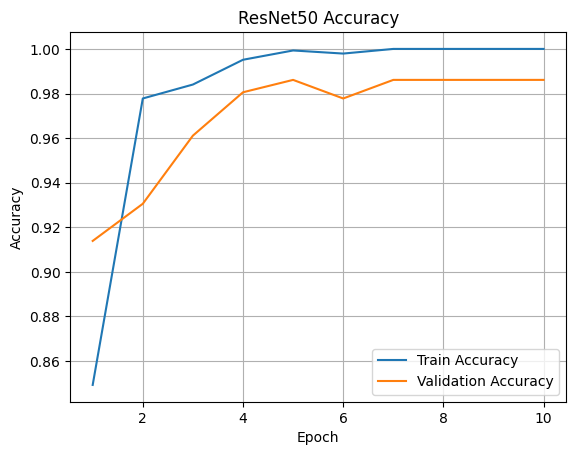

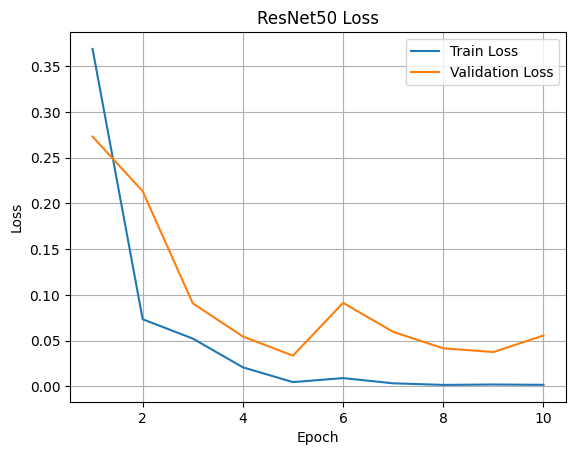

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

epochs = 10

resnet50.eval()
all_preds = []
all_labels = []
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet50(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(all_labels)
y_pred = np.array(all_preds)

# Compute metrics
resnet_metrics = {
    'Accuracy': round(correct / total, 2),
    'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
    'Recall': round(recall_score(y_true, y_pred, average='weighted'), 4),
    'F1 Score': round(f1_score(y_true, y_pred, average='weighted'), 4)
}

# Print metrics
print("ResNet50 Evaluation Metrics:")
for key, value in resnet_metrics.items():
    if key != 'Model':
        print(f"{key}: {value}")

# Accuracy plot
plt.plot(range(1, epochs+1), rn_train_accuracies, label='Train Accuracy')
plt.plot(range(1, epochs+1), rn_val_accuracies, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.plot(range(1, epochs+1), rn_train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), rn_val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import torch

# Save the model state dictionary (recommended for PyTorch)
torch.save(resnet50.state_dict(), 'lung-cancer-severity.h5')

# Save the entire model object
torch.save(resnet50, 'lung-cancer-severity.keras')

print("Model saved as lung-cancer-severity.keras and lung-cancer-severity.h5")

Model saved as lung-cancer-severity.keras and lung-cancer-severity.h5


In [8]:
import pandas as pd

# Create a summary table from the metrics
metrics_df = pd.DataFrame([resnet_metrics])

print("Ringkasan Performa Model ResNet50:")
display(metrics_df)

Ringkasan Performa Model ResNet50:


,Accuracy,Precision,Recall,F1 Score
0,0.99,0.9864,0.9861,0.9861


Detailed Classification Report:
                 precision    recall  f1-score   support

   Bengin cases       0.96      0.99      0.98       103
Malignant cases       1.00      1.00      1.00       132
   Normal cases       0.99      0.97      0.98       125

       accuracy                           0.99       360
      macro avg       0.98      0.99      0.99       360
   weighted avg       0.99      0.99      0.99       360


Model Confidence Statistics:
- Average Confidence: 99.43%
- Max Confidence: 100.00%
- Min Confidence: 59.10%


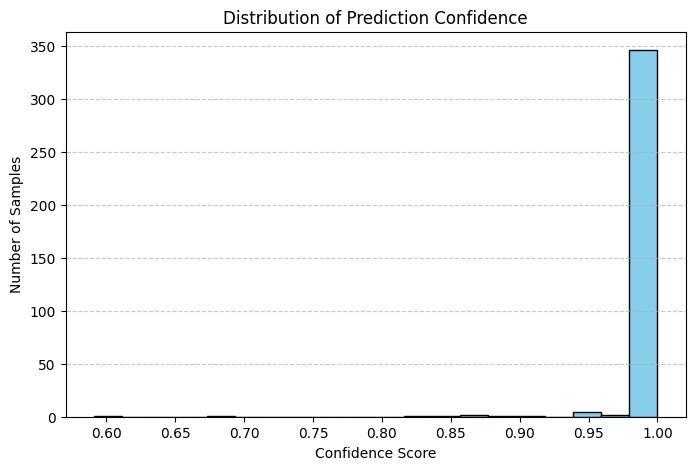

In [9]:
from sklearn.metrics import classification_report
import torch.nn.functional as F

# 1. Classification Report per Class
print("Detailed Classification Report:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# 2. Calculate Confidence Scores
all_confidences = []
resnet50.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = resnet50(images)
        probabilities = F.softmax(outputs, dim=1)
        conf, _ = torch.max(probabilities, dim=1)
        all_confidences.extend(conf.cpu().numpy())

avg_confidence = np.mean(all_confidences)
max_confidence = np.max(all_confidences)
min_confidence = np.min(all_confidences)

print(f"\nModel Confidence Statistics:")
print(f"- Average Confidence: {avg_confidence:.2%}")
print(f"- Max Confidence: {max_confidence:.2%}")
print(f"- Min Confidence: {min_confidence:.2%}")

# Visualize confidence distribution
plt.figure(figsize=(8, 5))
plt.hist(all_confidences, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Prediction Confidence")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [10]:
import torch
import torch.onnx

# Ensure model is in evaluation mode
resnet50.eval()

# 1. TORCHSCRIPT (Recommended for PyTorch Production)
example_input = torch.rand(1, 3, 512, 512).to(device)
traced_script_module = torch.jit.trace(resnet50, example_input)
traced_script_module.save("lung_cancer_model_production.pt")

# 2. ONNX (Updated to Opset 18 to avoid conversion errors)
# We use dynamic_shapes for compatibility with the newer Dynamo-based exporter
torch.onnx.export(
    resnet50, 
    example_input, 
    "lung_cancer_model.onnx", 
    export_params=True, 
    opset_version=18, 
    do_constant_folding=True, 
    input_names=['input'], 
    output_names=['output'],
    dynamic_axes={'input' : {0 : 'batch_size'}, 'output' : {0 : 'batch_size'}}
)

print("Production models exported successfully with updated configuration:")
print("- lung_cancer_model_production.pt (TorchScript)")
print("- lung_cancer_model.onnx (ONNX Opset 18)")

ModuleNotFoundError: No module named 'onnxscript'